In [1]:
%cd /mnt/c/projects/Sequence_Jupyter_Local/

/mnt/c/projects/Sequence_Jupyter_Local


In [2]:
import pysam
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from freq_analysis import match_percentage, frequency_pipeline, threshold_processor, itr_classifier, egfp_cassette_by_qpcr, count_formatter

In [4]:
def count_itr_distr(bamfile: str, itr_range: list) -> list:
    final_lengths = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            aligned_bases = 0
            pairs = read.get_aligned_pairs(matches_only=True, with_seq=True)
            for query_pos, ref_pos, base in pairs:
                if ref_pos is not None and itr_range[0] <= ref_pos < itr_range[1]:
                    #count mutations
                    #lowercase/mismatch is skipped
                    if base != 's' and base == base.lower():
                        continue
                    else:
                        aligned_bases += 1
            final_lengths.append(aligned_bases)
    return final_lengths

## WT_nopmll_nanopore

In [5]:
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/wt_nopmll_nanopore_md.bam"
itr_range = [2925,3069+1]
wt_nopmll = count_itr_distr(bamfile, itr_range)
max(wt_nopmll)

145

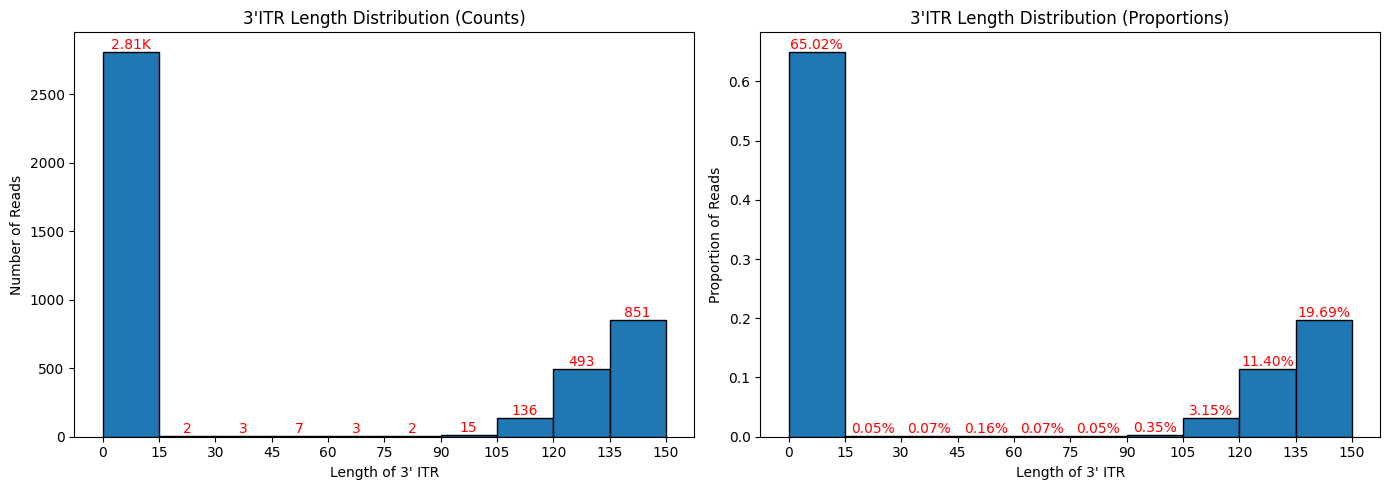

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(wt_nopmll, color="#1f77b4", edgecolor="black", bins=np.arange(0, 165, 15))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 165, 15))

_, _, bars = axes[1].hist(wt_nopmll, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 165, 15),
                            weights=np.ones(len(wt_nopmll)) / len(wt_nopmll))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 165, 15))
plt.tight_layout()

## dBC_nopmll_nanopore

111


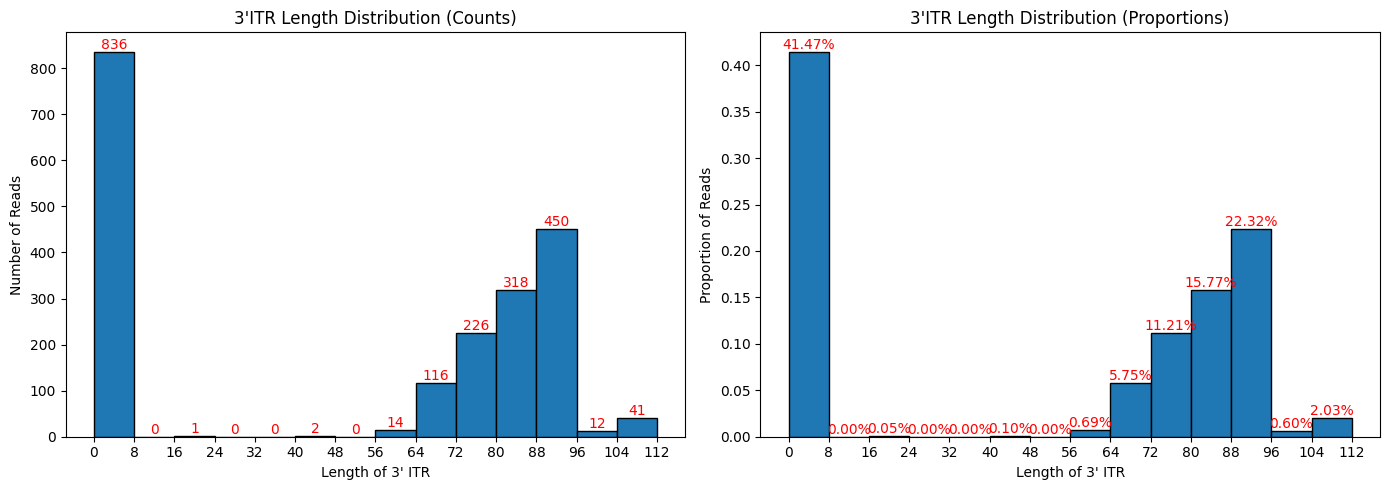

In [7]:
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/dbc_nopmll_nanopore_md.bam"
itr_range = [2891,3001+1]
dbc_nopmll = count_itr_distr(bamfile, itr_range)
print(max(dbc_nopmll))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll, color="#1f77b4", edgecolor="black", bins=np.arange(0, 120, 8))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 120, 8))

_, _, bars = axes[1].hist(dbc_nopmll, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 120, 8),
                            weights=np.ones(len(dbc_nopmll)) / len(dbc_nopmll))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 120, 8))
plt.tight_layout()

104

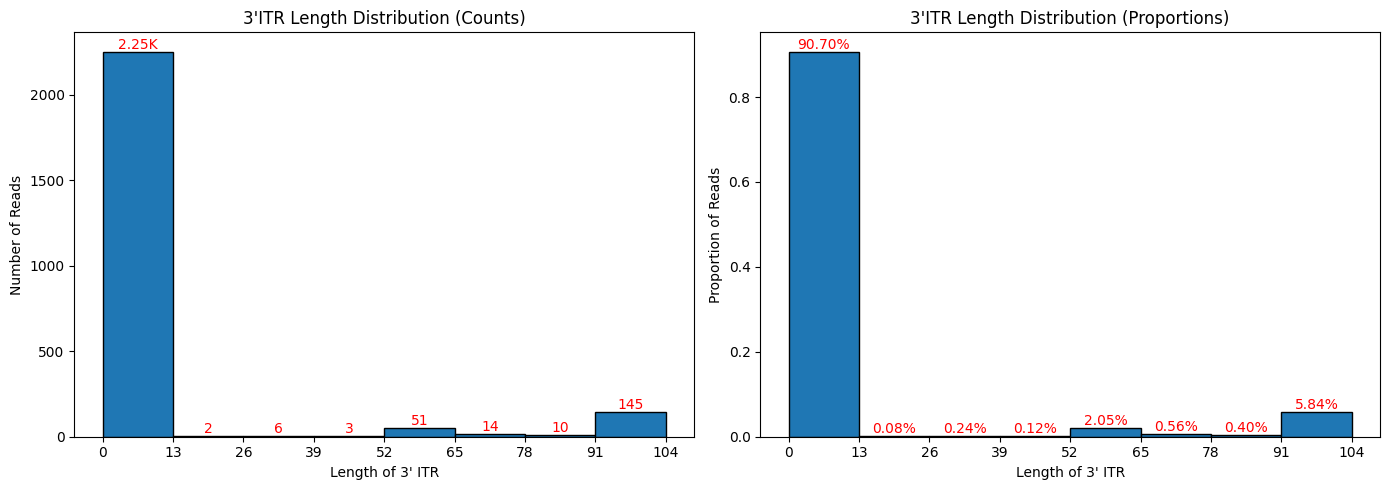

In [8]:
bamfile = "all_data/itr_reanalysis_data/98JB2Q_fastq/hybrid_nopmll_md.bam"
itr_range = [661, 764+1]
dbc_nopmll = count_itr_distr(bamfile, itr_range)
max(dbc_nopmll)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll, color="#1f77b4", edgecolor="black", bins=np.arange(0, 117, 13))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 117, 13))

_, _, bars = axes[1].hist(dbc_nopmll, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 117, 13),
                            weights=np.ones(len(dbc_nopmll)) / len(dbc_nopmll))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 117, 13))
plt.tight_layout()
wt_nopmll = count_itr_distr(bamfile, itr_range)
max(wt_nopmll)

# Sequence Alignment Library Test

In [9]:
from Bio import Align

In [10]:
aligner = Align.PairwiseAligner()
# fast optimal global alignment algorithm
target = "AGGAACCCCTAGTGATGGAGTTGGCCACTCCCTCTCTGCGCGCTCGCTCGCTCACTGAGGCCGGGCGACCAAAGGTCGCCCGACGCCCGGGCTTTGCCCGGGCGGCCTCAGTGAGCGAGCGAGCGCGCAGAGAGGGAGTGGCCAA"
query = "AGGAACCCCTAGTGATGGAGTTGGCCACTCCCTCTCTGCGCGCTCGCTCGCTCACTGAGGCCGGCCTCAGTGAGCGAGCGAGCGCGCAGAGAGGGAGTGGCCAA"
alignments = aligner.align(target, query)
score = aligner.score(target, query)
score

104.0

In [11]:
def count_itr_distr(bamfile: str, itr_range: list) -> list:
    final_lengths = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            aligned_bases = 0
            pairs = read.get_aligned_pairs(matches_only=True, with_seq=True)
            for query_pos, ref_pos, base in pairs:
                if ref_pos is not None and itr_range[0] <= ref_pos < itr_range[1]:
                    #count mutations
                    #lowercase/mismatch is skipped
                    if base != 's' and base == base.lower():
                        continue
                    else:
                        aligned_bases += 1
            final_lengths.append(aligned_bases)
    return final_lengths

In [12]:
def repaired_freq(bamfile: str, target_a: str, target_b: str) -> list:
    bam = pysam.AlignmentFile(bamfile)
    aligner = Align.PairwiseAligner()
    all_scores = []
    for read in bam.fetch():
        query = read.query_sequence
        score = aligner.score(target_a, query)
        all_scores.append(score)
    return all_scores


In [13]:
bamfile = "all_data/itr_reanalysis_data/98JB2Q_fastq/hybrid_nopmll_md.bam"
WT_3ITR = "AGGAACCCCTAGTGATGGAGTTGGCCACTCCCTCTCTGCGCGCTCGCTCGCTCACTGAGGCCGGGCGACCAAAGGTCGCCCGACGCCCGGGCTTTGCCCGGGCGGCCTCAGTGAGCGAGCGAGCGCGCAGAGAGGGAGTGGCCAA"
HYBRID_3ITR = "AGGAACCCCTAGTGATGGAGTTGGCCACTCCCTCTCTGCGCGCTCGCTCGCTCACTGAGGCCGGCCTCAGTGAGCGAGCGAGCGCGCAGAGAGGGAGTGGCCAA"
wt = repaired_freq(bamfile, WT_3ITR, HYBRID_3ITR)

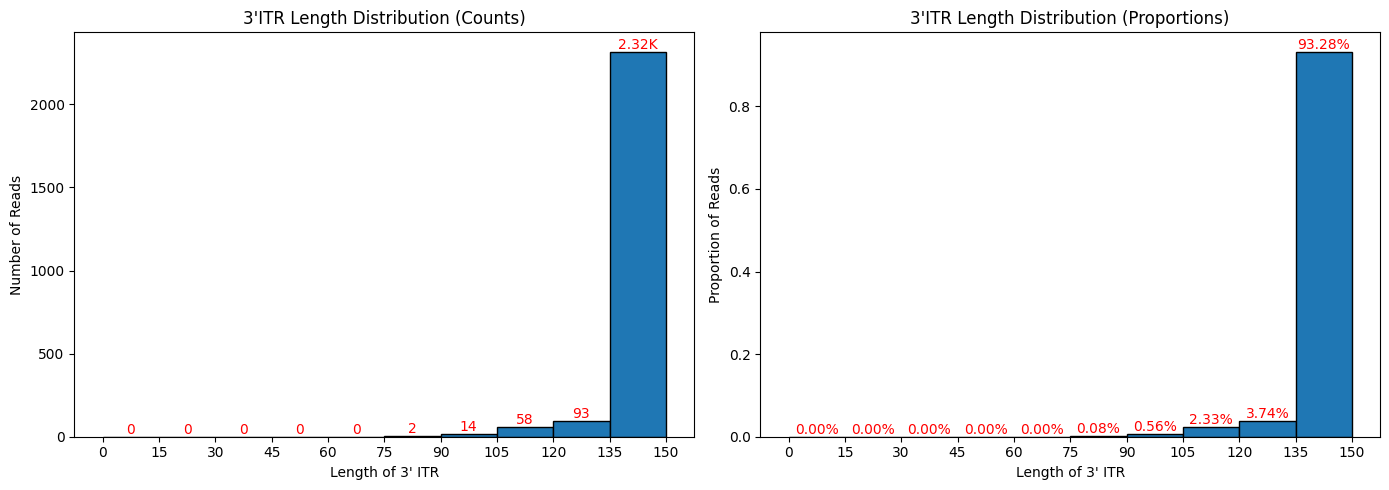

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_, _, bars = axes[0].hist(wt, color="#1f77b4", edgecolor="black", bins=np.arange(0, 165, 15))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 165, 15))

_, _, bars = axes[1].hist(wt, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 165, 15),
                            weights=np.ones(len(wt)) / len(wt))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 165, 15))
plt.tight_layout()

# Align to WT baseline 

## Count Deletions on hybrid aligned to basecase

In [ ]:
def count_deletions(bamfile: str, itr_range: list, virus_type: str, itr_type=True) -> list:
    final_dels = []
    final_pos = []
    bam = pysam.AlignmentFile(bamfile)
    partials = 0
    total_reads = 0
    ORIG_LEN = 145
        
    if virus_type == "wt":
        REPAIR_LEN = 121
        DEL_RANGE = ORIG_LEN-REPAIR_LEN
    elif virus_type == "dbc":
        if itr_type == True:
            ITR = "3'"
            REP_LEN = 121
        else:
            ITR = "5'"
            REP_LEN = 118
        ACTUAL_LEN = 111
        DEL_RANGE = REP_LEN - ACTUAL_LEN

    else: 
        if itr_type == True:
            ITR = "3'"
            REP_LEN = 145
        else:
            ITR = "5'"
            REP_LEN = 145
        ACTUAL_LEN = 104
        DEL_RANGE = REP_LEN - ACTUAL_LEN

         
    for read in bam.fetch():
            total_reads += 1 
            deletions = 0
            pairs = read.get_aligned_pairs(matches_only=False)
            for query_pos, ref_pos in pairs:
                if ref_pos is not None and itr_range[0] <= ref_pos < itr_range[1]:
                    if query_pos is None:
                        deletions += 1
            if deletions < 41 and deletions > 0:
                 partials += 1
            final_dels.append(deletions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _, _, bars = axes[0].hist(final_dels, color="#1f77b4", edgecolor="black", bins=np.arange(0, 150, 5))
    axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
    axes[0].set_title("3'ITR Length Distribution (Counts)")
    axes[0].set_xlabel("Number of Deletions in 3' ITR Region")
    axes[0].set_ylabel("Number of Reads")
    axes[0].set_xticks(np.arange(0, 150, 5))

    _, _, bars = axes[1].hist(final_dels, color="#1f77b4", edgecolor="black",
                                bins=np.arange(0, 150, 5),
                                weights=np.ones(len(final_dels)) / len(final_dels))
    axes[1].bar_label(bars, color="red", fmt='{:.2%}')
    axes[1].set_title("3'ITR Length Distribution (Proportions)")
    axes[1].set_xlabel("Number of Deletions in 3' ITR Region")
    axes[1].set_ylabel("Proportion of Reads")
    axes[1].set_xticks(np.arange(0, 150, 5))
    plt.tight_layout()
    print(max(final_dels))
    print(f"{partials} reads have any {ITR} insertions, {(partials/total_reads)*100:.2f}% of total reads have any insertions\n" + 
          f"Of those, {repairs} reads repaired back to {REPAIR_LEN}, {(repairs/total_reads)*100:.2f}% of total reads are within the repair zone")
    return

# 3' 

42


'221 Partially repaired reads, fraction of reads repaired is 8.89%'

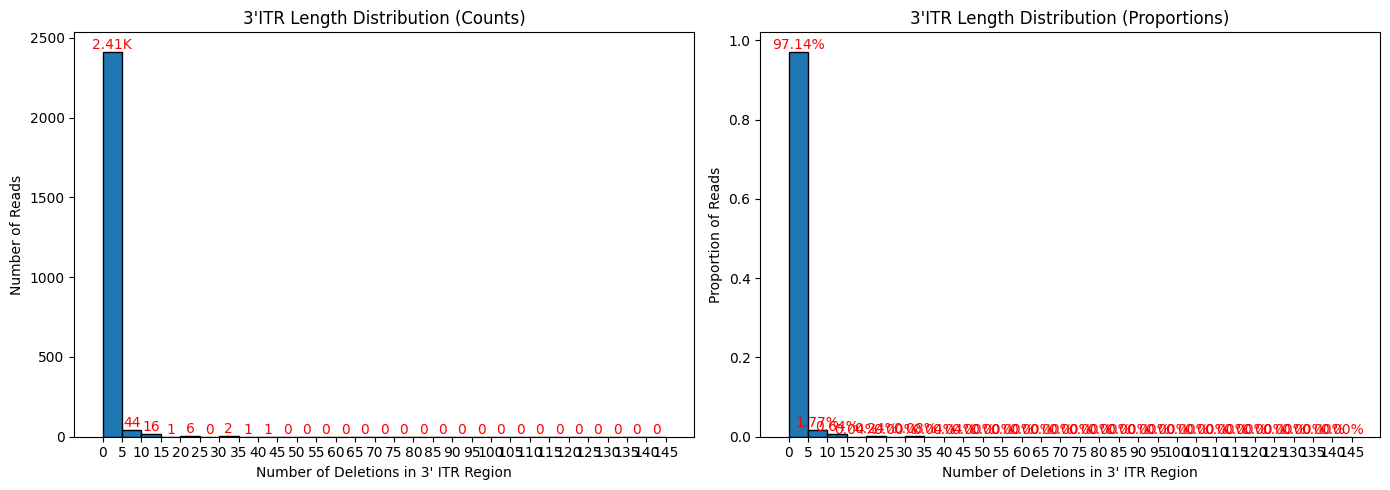

In [34]:
bamfile = "all_data/itr_reanalysis_data/hybrid_wt_alignment/hybrid_WT_final.bam"
wt_hybrid_cigar = count_deletions(bamfile,[2925, 3070])
wt_hybrid_cigar

75


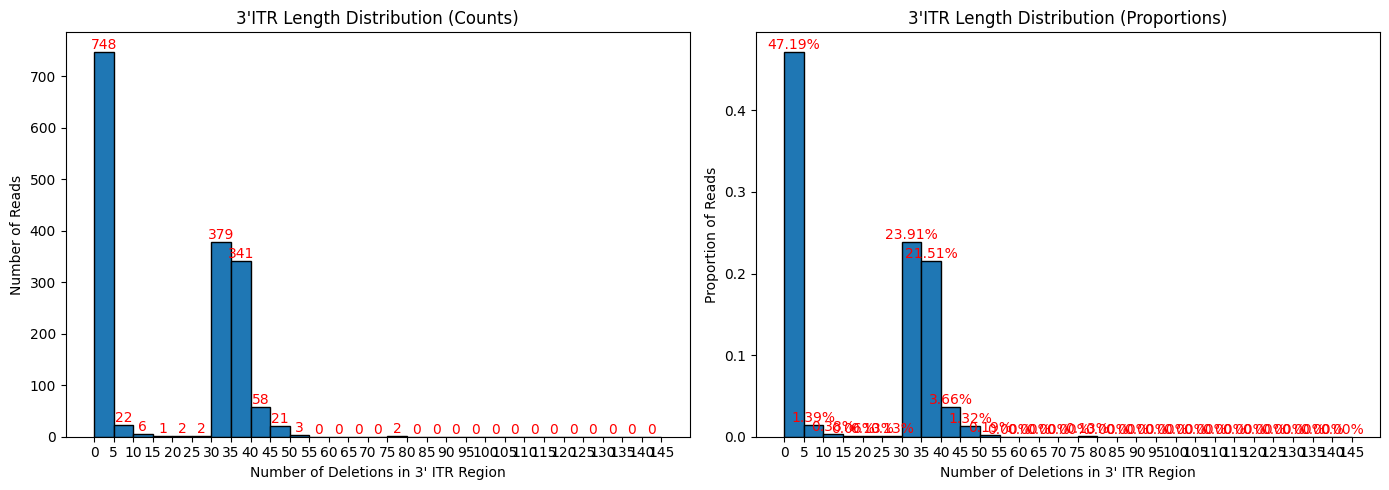

In [ ]:
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
dbc_no_pml = count_deletions(bamfile,[2925, 3070])

## Count Insertions

In [98]:
def count_insertions(bamfile: str, itr_range: list, itr_type= True) -> list:
    final_ins = []
    final_pos = []
    bam = pysam.AlignmentFile(bamfile)
    partials = 0
    repairs = 0
    total_reads = 0
    if itr_type == True:
        ITR = "3'"
        REPAIR_LEN = 121
        REPAIR_INS = 10
    else:
        ITR = "5'"
        REPAIR_LEN = 118
        REPAIR_INS = 7
    for read in bam.fetch():
            total_reads += 1 
            insertions = 0
            pairs = read.get_aligned_pairs(matches_only=False)
            last_ref_pos = None
            for query_pos, ref_pos in pairs:
                if ref_pos is not None:
                    last_ref_pos = ref_pos
                elif ref_pos is None and query_pos is not None:
                    if last_ref_pos is not None and itr_range[0] <= last_ref_pos <= itr_range[1]:
                        insertions += 1
            if insertions < 41 and insertions > 0:
                 partials += 1
            if insertions <= REPAIR_INS and insertions > 0:
                 repairs += 1
            final_ins.append(insertions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _, _, bars = axes[0].hist(final_ins, color="#1f77b4", edgecolor="black", bins=np.arange(0, 45, 3))
    axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
    axes[0].set_title(f"{ITR}ITR Length Distribution (Counts)")
    axes[0].set_xlabel(f"Insertion Length Per {ITR}ITR Read")
    axes[0].set_ylabel("Number of Reads")
    axes[0].set_xticks(np.arange(0, 45, 3))

    _, _, bars = axes[1].hist(final_ins, color="#1f77b4", edgecolor="black",
                                bins=np.arange(0, 45, 3),
                                weights=np.ones(len(final_ins)) / len(final_ins))
    axes[1].bar_label(bars, color="red", fmt='{:.2%}')
    axes[1].set_title(f"{ITR}ITR Length Distribution (Proportions)")
    axes[1].set_xlabel(f"Insertion Length Per {ITR}ITR Read")
    axes[1].set_ylabel("Proportion of Reads")
    axes[1].set_xticks(np.arange(0, 45, 3))
    plt.tight_layout()
    print(max(final_ins))
    print(f"{partials} reads have any {ITR} insertions, {(partials/total_reads)*100:.2f}% of total reads have any insertions\n" + 
          f"Of those, {repairs} reads repaired back to {REPAIR_LEN}, {(repairs/total_reads)*100:.2f}% of total reads are within the repair zone")
    return 

# 3'

583
330 reads have any 3' insertions, 13.28% of total reads have any insertions
Of those, 300 reads repaired back to 121, 12.07% of total reads are within the repair zone


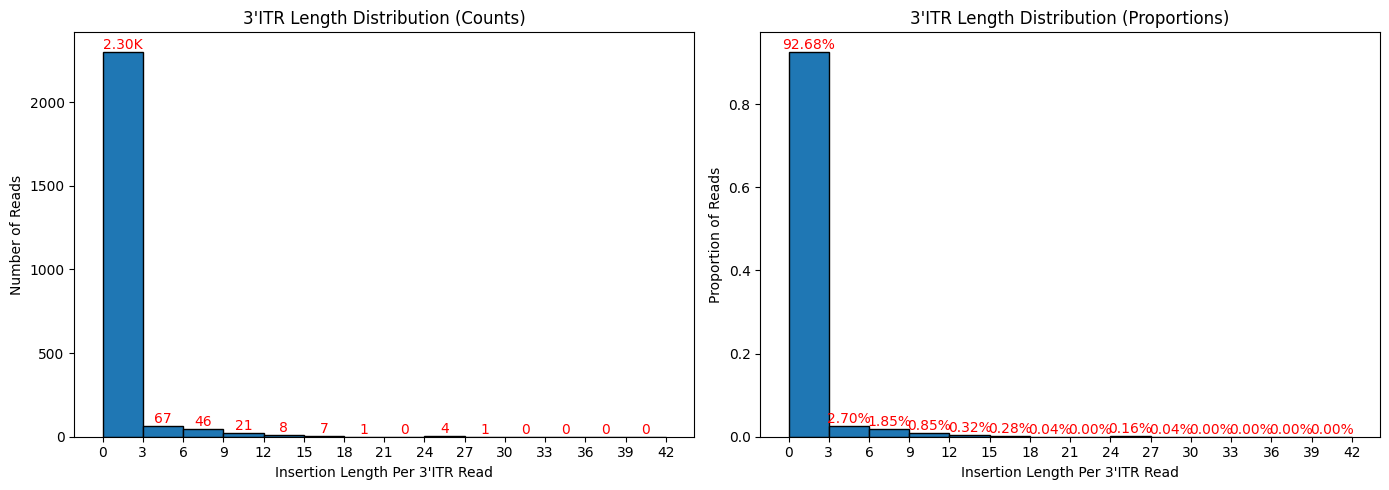

In [119]:
bamfile = "all_data/itr_reanalysis_data/hybrid_wt_alignment/hybrid_WT_final.bam"
wt_hybrid = count_insertions(bamfile,[2925, 3070])
wt_hybrid

987
1216 reads have any 3' insertions, 28.13% of total reads have any insertions
Of those, 1137 reads repaired back to 121, 26.30% of total reads are within the repair zone


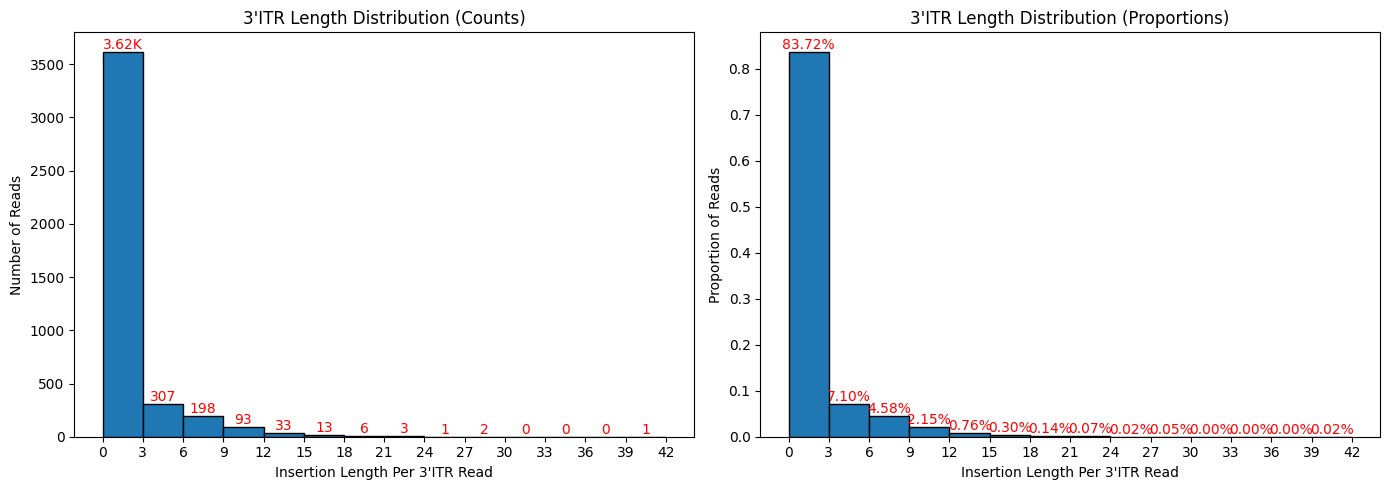

In [106]:
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/wt_nopmll_nanopore_md.bam"
wt_no_pml = count_insertions(bamfile,[2925, 3070])
wt_no_pml

1089
318 reads have any 3' insertions, 20.06% of total reads have any insertions
Of those, 306 reads repaired back to 121, 19.31% of total reads are within the repair zone


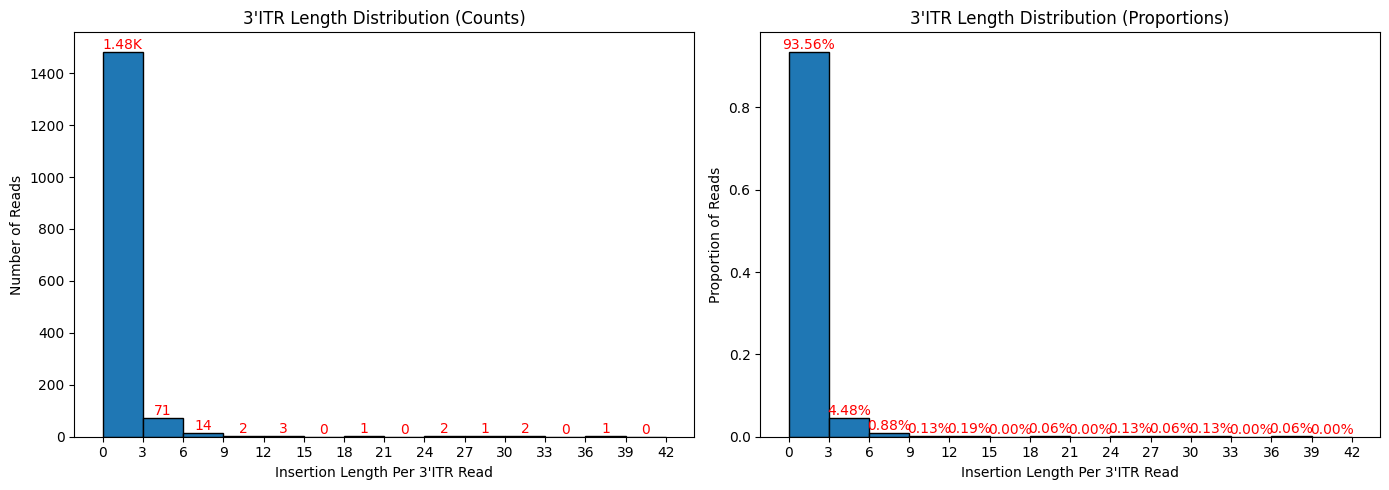

In [117]:
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
dbc_no_pml = count_insertions(bamfile,[2925, 3070])

# 5'

3174
940 reads have any 5' insertions, 37.83% of total reads have any insertions
Of those, 904 reads repaired back to 118, 36.38% of total reads are within the repair zone


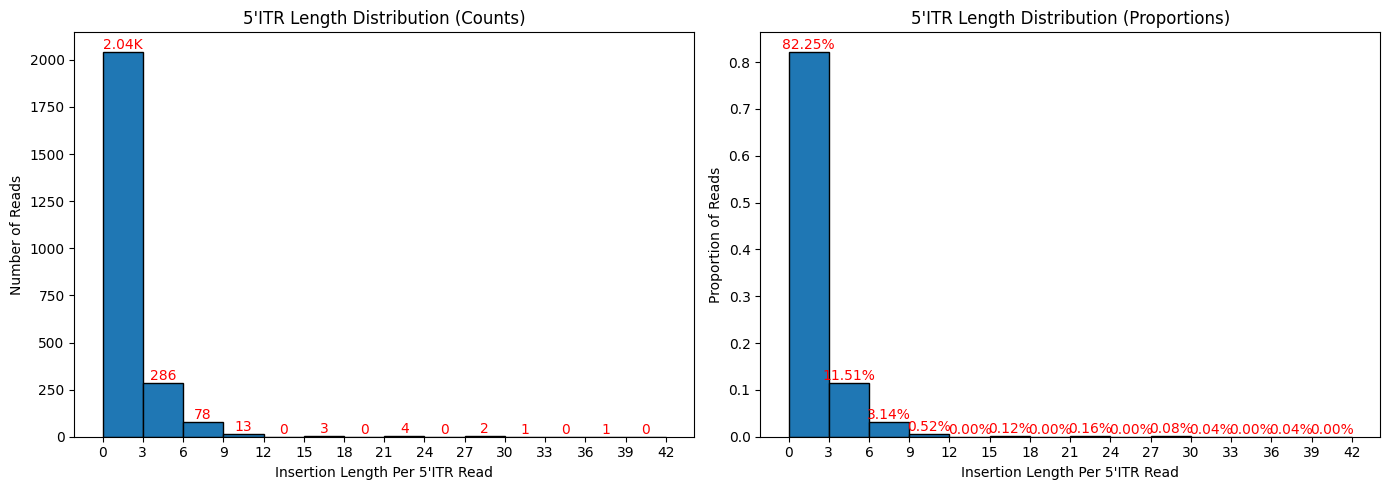

In [115]:
bamfile = "all_data/itr_reanalysis_data/hybrid_wt_alignment/hybrid_WT_final.bam"
wt_hybrid = count_insertions(bamfile,[195, 340], False)
wt_hybrid

1098
1106 reads have any 5' insertions, 25.58% of total reads have any insertions
Of those, 1058 reads repaired back to 118, 24.47% of total reads are within the repair zone


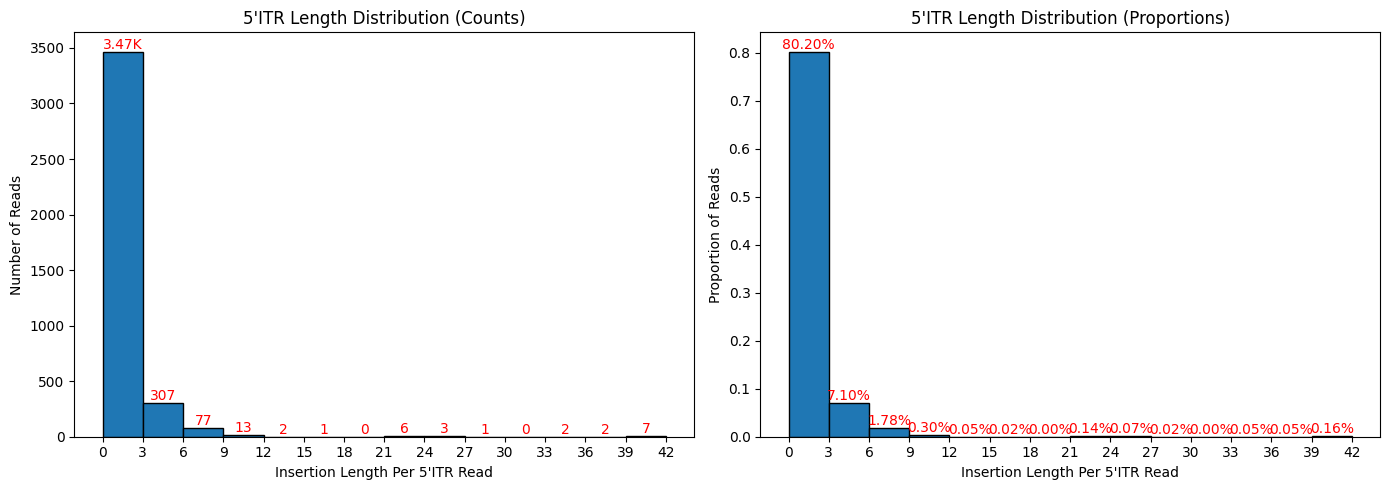

In [116]:
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/wt_nopmll_nanopore_md.bam"
wt_no_pml = count_insertions(bamfile,[195, 340], False)
wt_no_pml

942
85 reads have any 5' insertions, 5.36% of total reads have any insertions
Of those, 76 reads repaired back to 118, 4.79% of total reads are within the repair zone


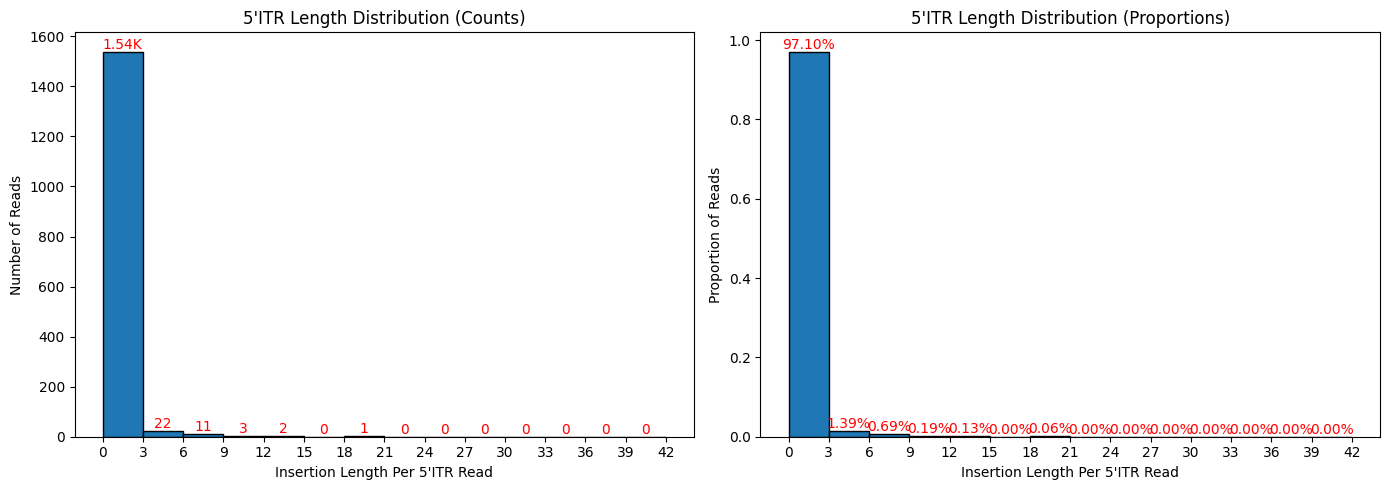

In [118]:
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
dbc_no_pml = count_insertions(bamfile,[195, 340], False)
dbc_no_pml